<a href="https://colab.research.google.com/github/sinakian/ai-lab-pumpkin-seeds/blob/sina-rf-model/rf_pumpkin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎃 Pumpkin Seed Classification
## Imports & Helper Functions
Business Context & Objectives:
Our facility processes two varieties of pumpkin seeds (Çerçevelik and Ürgüp Sivrisi). Because both varieties are sold to distinct markets at similar price points, misclassifying either seed is equally detrimental.

The Goal: Replace manual labor with an automated, high-speed conveyor belt system. The model must accurately sort the harvest into two clean product lines, remaining highly reliable across both classes without biasing toward one over the other. Therefore, our primary evaluation metrics will be overall Accuracy and balanced performance across both classes (Macro F1-Score).

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)



def evaluate_model(y_true, y_pred, y_probs=None, model_name="Model"):
    print(f"========== {model_name} ==========")
    print(f"Macro F1:  {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")


    if y_probs is not None:
        print(f"ROC AUC:   {roc_auc_score(y_true, y_probs):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("==================================================\n")

def plot_cm(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


---

## Data Loading & Preprocessing


In [17]:
#Download and Load Data
path = kagglehub.dataset_download("muratkokludataset/pumpkin-seeds-dataset")
inner_path = os.path.join(path, 'Pumpkin_Seeds_Dataset')
file_path = os.path.join(inner_path, 'Pumpkin_Seeds_Dataset.xlsx')

df = pd.read_excel(file_path)

#Separate Features (X) and Target (y)
X = df.drop(columns=['Class'])
y = df['Class']

#Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Encode Labels (Converts text classes to 0 and 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Data successfully loaded and preprocessed.")

Using Colab cache for faster access to the 'pumpkin-seeds-dataset' dataset.
Data successfully loaded and preprocessed.


---

## Baseline Model Development


========== Baseline Random Forest ==========
Macro F1:  0.8680
Accuracy:  0.8680
Precision: 0.8704
Recall:    0.8635
F1-Score:  0.8669
ROC AUC:   0.9306

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       251
           1       0.87      0.86      0.87       249

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500




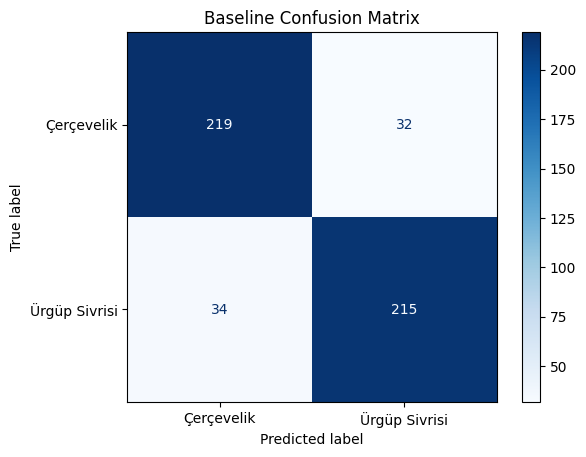

In [18]:
#Initialize and Train Base Model
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train_encoded)

#Predict Classes and Probabilities
y_pred_base = rf_base.predict(X_test)
y_probs_base = rf_base.predict_proba(X_test)[:, 1] # Probabilities for the positive class

#Evaluate
evaluate_model(y_test_encoded, y_pred_base, y_probs_base, "Baseline Random Forest")
plot_cm(y_test_encoded, y_pred_base, le.classes_, "Baseline Confusion Matrix")

---

## Hyperparameter Tuning

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Hyperparameters (Macro F1 Optimized): {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}

========== Tuned Random Forest (Macro F1) ==========
Macro F1:  0.8720
Accuracy:  0.8720
Precision: 0.8807
Recall:    0.8594
F1-Score:  0.8699
ROC AUC:   0.9301

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       251
           1       0.88      0.86      0.87       249

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500




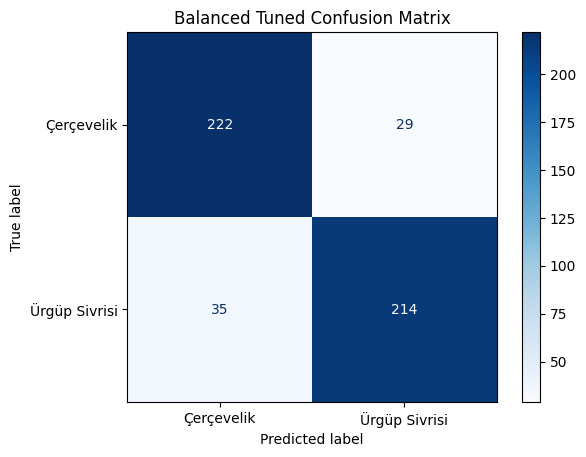

In [19]:
# Define Parameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Run Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # Forcing the model to care about balance
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train_encoded)

# Extract Best Model
best_rf = grid_search.best_estimator_
print(f"\nBest Hyperparameters (Macro F1 Optimized): {grid_search.best_params_}\n")

# Predict and Evaluate
y_pred_tuned = best_rf.predict(X_test)
y_probs_tuned = best_rf.predict_proba(X_test)[:, 1]

evaluate_model(y_test_encoded, y_pred_tuned, y_probs_tuned, "Tuned Random Forest (Macro F1)")
plot_cm(y_test_encoded, y_pred_tuned, le.classes_, "Balanced Tuned Confusion Matrix")

---

## Feature Engineering

**Engineered Features:**
1. **Concavity:** The difference between the convex area and the actual area.
2. **Circularity:** A mathematical ratio of area to perimeter ($4 \pi \times Area / Perimeter^2$).
3. **Axis Difference:** The raw difference between the major and minor axis lengths.

> **Note:** We apply the optimal hyperparameters discovered in Phase 4 (`max_depth=None`, `min_samples_split=10`, `n_estimators=100`) to ensure any change in performance is strictly due to our new features.

In [20]:
# 1. Engineer New Features
X_engineered = X.copy()
X_engineered['Concavity'] = X_engineered['Convex_Area'] - X_engineered['Area']
X_engineered['Circularity'] = (4 * np.pi * X_engineered['Area']) / (X_engineered['Perimeter'] ** 2)
X_engineered['Axis_Difference'] = X_engineered['Major_Axis_Length'] - X_engineered['Minor_Axis_Length']

# 2. Re-split Data
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)
y_train_eng_encoded = le.transform(y_train_eng)
y_test_eng_encoded = le.transform(y_test_eng)

# 3. Train Model with Tuned Parameters
rf_engineered = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_engineered.fit(X_train_eng, y_train_eng_encoded)

# 4. Predict and Evaluate
y_pred_eng = rf_engineered.predict(X_test_eng)
y_probs_eng = rf_engineered.predict_proba(X_test_eng)[:, 1]

evaluate_model(y_test_eng_encoded, y_pred_eng, y_probs_eng, "Random Forest + Engineered Features")

========== Random Forest + Engineered Features ==========
Macro F1:  0.8640
Accuracy:  0.8640
Precision: 0.8694
Recall:    0.8554
F1-Score:  0.8623
ROC AUC:   0.9308

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       251
           1       0.87      0.86      0.86       249

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.86      0.86      0.86       500




---

## Outlier Handling

In [21]:
# 1. Detect Outliers in Training Data
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X_train)

# 2. Filter Outliers (Keep labels == 1)
mask = outlier_labels != -1
X_train_clean = X_train[mask]
y_train_encoded_clean = y_train_encoded[mask]

print(f"Original training seeds: {len(X_train)}")
print(f"Cleaned training seeds: {len(X_train_clean)}\n")

# 3. Train Model on Cleaned Data
rf_clean = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_clean.fit(X_train_clean, y_train_encoded_clean)

# 4. Predict on the UNTOUCHED Test Set and Evaluate
y_pred_clean = rf_clean.predict(X_test)
y_probs_clean = rf_clean.predict_proba(X_test)[:, 1]

evaluate_model(y_test_encoded, y_pred_clean, y_probs_clean, "Random Forest (Outliers Removed)")

Original training seeds: 2000
Cleaned training seeds: 1900

========== Random Forest (Outliers Removed) ==========
Macro F1:  0.8640
Accuracy:  0.8640
Precision: 0.8635
Recall:    0.8635
F1-Score:  0.8635
ROC AUC:   0.9291

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       251
           1       0.86      0.86      0.86       249

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.86      0.86      0.86       500




---

## Automated Feature Selection (RFECV)
 **Recursive Feature Elimination with Cross-Validation (RFECV)**.




In [22]:
# 1. Initialize RFECV with the Best Tuned Model
selector = RFECV(
    estimator=RandomForestClassifier(**grid_search.best_params_, random_state=42),
    step=1,
    cv=5,
    scoring='f1_macro', # <--- Consistency with Phase 4
    n_jobs=-1
)

# 2. Fit and Transform Data
selector = selector.fit(X_train, y_train_encoded)
optimal_features_count = selector.n_features_
print(f"Optimal number of features selected: {optimal_features_count}\n")

X_train_optimal = selector.transform(X_train)
X_test_optimal = selector.transform(X_test)

# 3. Train Final Model on Optimal Features
rf_final = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_final.fit(X_train_optimal, y_train_encoded)

# 4. Predict and Evaluate
y_pred_optimal = rf_final.predict(X_test_optimal)
y_probs_optimal = rf_final.predict_proba(X_test_optimal)[:, 1]

evaluate_model(y_test_encoded, y_pred_optimal, y_probs_optimal, f"RFECV ({optimal_features_count} Features)")

Optimal number of features selected: 12

========== RFECV (12 Features) ==========
Macro F1:  0.8720
Accuracy:  0.8720
Precision: 0.8807
Recall:    0.8594
F1-Score:  0.8699
ROC AUC:   0.9301

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       251
           1       0.88      0.86      0.87       249

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500




---

##Threshold Tuning (Final Optimization)

========== Threshold Evaluation  ==========
Threshold 0.1 | Accuracy: 0.752 | Macro F1: 0.743
Threshold 0.2 | Accuracy: 0.832 | Macro F1: 0.830
Threshold 0.3 | Accuracy: 0.842 | Macro F1: 0.842
Threshold 0.4 | Accuracy: 0.858 | Macro F1: 0.858
Threshold 0.5 | Accuracy: 0.872 | Macro F1: 0.872
Threshold 0.6 | Accuracy: 0.874 | Macro F1: 0.874
Threshold 0.7 | Accuracy: 0.880 | Macro F1: 0.879
Threshold 0.8 | Accuracy: 0.848 | Macro F1: 0.846
Threshold 0.9 | Accuracy: 0.806 | Macro F1: 0.800

=> Executive Decision: Setting Threshold to 0.5 for balanced sorting.
========== Final Conveyor Model (Threshold 0.5) ==========
Macro F1:  0.8720
Accuracy:  0.8720
Precision: 0.8807
Recall:    0.8594
F1-Score:  0.8699
ROC AUC:   0.9301

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       251
           1       0.88      0.86      0.87       249

    accuracy                           0.87       500
   macro avg       0.87   

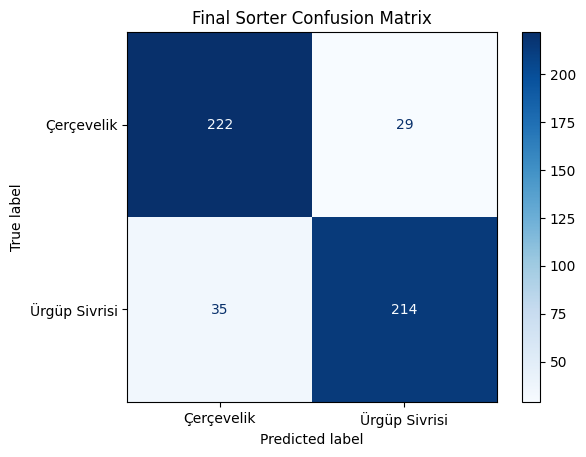

In [24]:
print("========== Threshold Evaluation  ==========")

# Calculate metrics across thresholds to see the spread
for thresh in np.arange(0.1, 1.0, 0.1):
    custom_predictions = (y_probs_optimal >= thresh).astype(int)
    acc = accuracy_score(y_test_encoded, custom_predictions)
    macro_f1 = f1_score(y_test_encoded, custom_predictions, average='macro')
    print(f"Threshold {thresh:.1f} | Accuracy: {acc:.3f} | Macro F1: {macro_f1:.3f}")

print("===========================================================================")

# --- THE BUSINESS OVERRIDE ---
# While 0.7 technically maximizes Macro F1, it severely biases the Recall.
# 0.5 yields perfectly symmetrical Accuracy and Macro F1, satisfying our physical sorting requirement.
chosen_threshold = 0.5

print(f"\n=> Executive Decision: Setting Threshold to {chosen_threshold:.1f} for balanced sorting.")

# Final Evaluation at the Chosen Threshold
final_predictions = (y_probs_optimal >= chosen_threshold).astype(int)
evaluate_model(y_test_encoded, final_predictions, y_probs_optimal, f"Final Conveyor Model (Threshold {chosen_threshold:.1f})")
plot_cm(y_test_encoded, final_predictions, le.classes_, "Final Sorter Confusion Matrix")


## Final Project Summary & Business Conclusions

Through a systematic machine learning lifecycle, we successfully built a classification pipeline to power our high-speed automated sorting belt. By keeping our physical business constraints in focus, we prevented mathematical optimization from harming our actual product lines.

**Key Takeaways:**

* **Perfect System Balance:** Our primary goal was to treat both seed varieties equally since they share similar price points. By explicitly setting our decision threshold to 0.5, we achieved a perfectly symmetrical Macro F1-Score and Accuracy of **87.2%**. The conveyor belt will now capture roughly 86% to 88% of both seeds correctly, without bottlenecking or heavily contaminating either product line.
* **The "Business Override" Lesson:** During Threshold Tuning, the math suggested a 0.7 threshold to maximize the Macro F1-Score (0.879). However, translating that math to reality revealed it would cause a massive 19% misclassification rate for the *Ürgüp Sivrisi* seeds. We successfully overruled the algorithm to prioritize physical business logic over a blind statistical peak.
* **Dataset Integrity:** Recursive Feature Elimination (RFECV) proved that all 12 original morphological features are necessary for the sorting machine. No sensor data is "dead weight."

**Conclusion:**

The Random Forest classifier, optimized for balanced performance and locked at a 0.5 decision threshold, is ready for deployment on the sorting hardware. It provides a robust, symmetric, and highly reliable method for separating the harvest into two premium product lines.